In [1]:
import json, glob, os
import pandas as pd
import matplotlib.pyplot as plt

def load_results(prefix):
    records = []
    for path in glob.glob(f"results/{prefix}_*.json"):
        with open(path) as f:
            records.append(json.load(f))
    if not records:
        return pd.DataFrame()
    df = pd.DataFrame(records)
    # Keep only the latest run per unique (adapter, operation, clients) combination
    df = df.sort_values("timestamp").groupby(["adapter", "operation", "clients"], as_index=False).last()
    return df


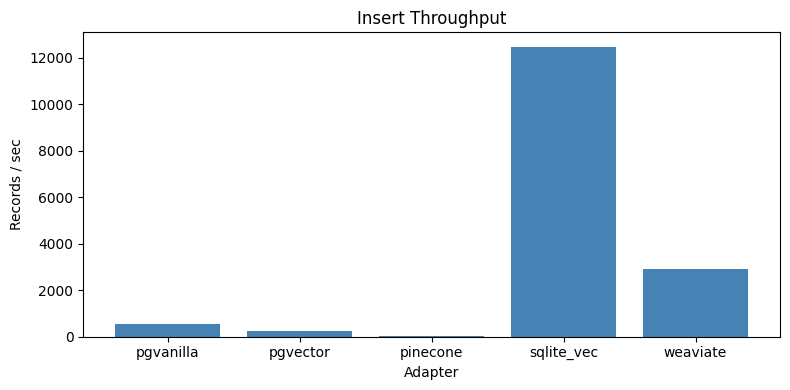

,adapter,records_per_sec
0,sqlite_vec,12464.33
1,weaviate,2890.30
2,pgvanilla,560.14
3,pgvector,230.01
4,pinecone,44.62


In [2]:
# Chart 1: Insert throughput (records/sec) per adapter
df = load_results("insert")
if df.empty:
    print("No insert results found. Run benchmark_insert.py first.")
else:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(df["adapter"], df["records_per_sec"], color="steelblue")
    ax.set_xlabel("Adapter")
    ax.set_ylabel("Records / sec")
    ax.set_title("Insert Throughput")
    plt.tight_layout()
    plt.show()
    display(df[["adapter", "records_per_sec"]].sort_values("records_per_sec", ascending=False).reset_index(drop=True))

**How to read this chart:** The adapter with the **tallest bar** has the highest insert throughput (records/sec) — that is the best choice for bulk ingestion workloads. If bars are close in height, the difference is negligible in practice.

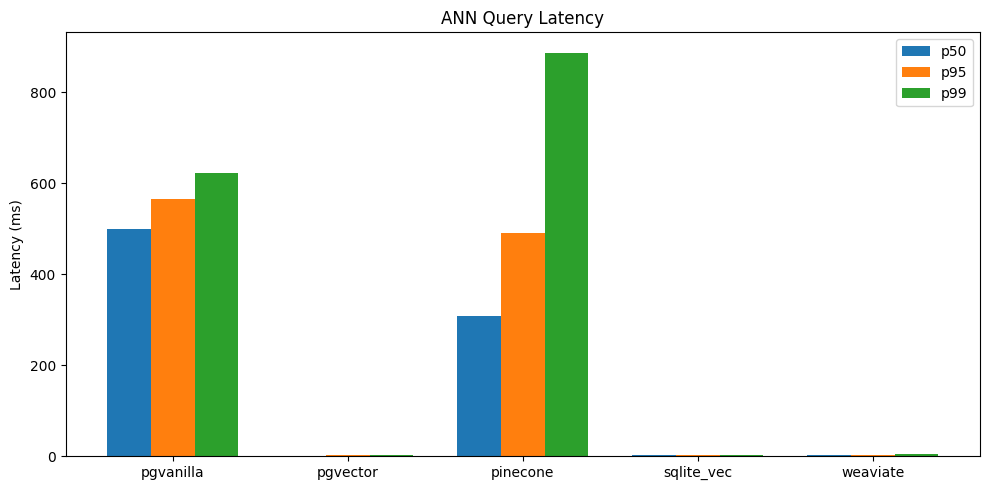

,adapter,p50_ms,p95_ms,p99_ms,qps
0,pgvector,1.335812,2.496915,3.436365,635.33
1,sqlite_vec,2.015095,2.361201,3.498521,456.51
2,weaviate,1.455408,2.376962,4.122558,576.22
3,pgvanilla,498.389268,565.152545,621.437001,1.97
4,pinecone,308.108607,491.100688,887.041692,2.99


In [3]:
# Chart 2: Query latency ANN (p50/p95/p99)
df = load_results("query")
df_ann = df[df["operation"] == "query_ann"]
if df_ann.empty:
    print("No ANN query results found. Run benchmark_query.py first.")
else:
    x = range(len(df_ann))
    width = 0.25
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar([i - width for i in x], df_ann["p50_ms"], width, label="p50")
    ax.bar(list(x), df_ann["p95_ms"], width, label="p95")
    ax.bar([i + width for i in x], df_ann["p99_ms"], width, label="p99")
    ax.set_xticks(list(x))
    ax.set_xticklabels(df_ann["adapter"].tolist())
    ax.set_ylabel("Latency (ms)")
    ax.set_title("ANN Query Latency")
    ax.legend()
    plt.tight_layout()
    plt.show()
    display(df_ann[["adapter", "p50_ms", "p95_ms", "p99_ms", "qps"]].sort_values("p99_ms").reset_index(drop=True))

**How to read this chart:** **Lower bars are better** (less latency). Prioritize p99 if tail latency matters (e.g. interactive search); p50 reflects the typical query experience. The adapter with the shortest p99 bar gives the most consistent ANN performance.

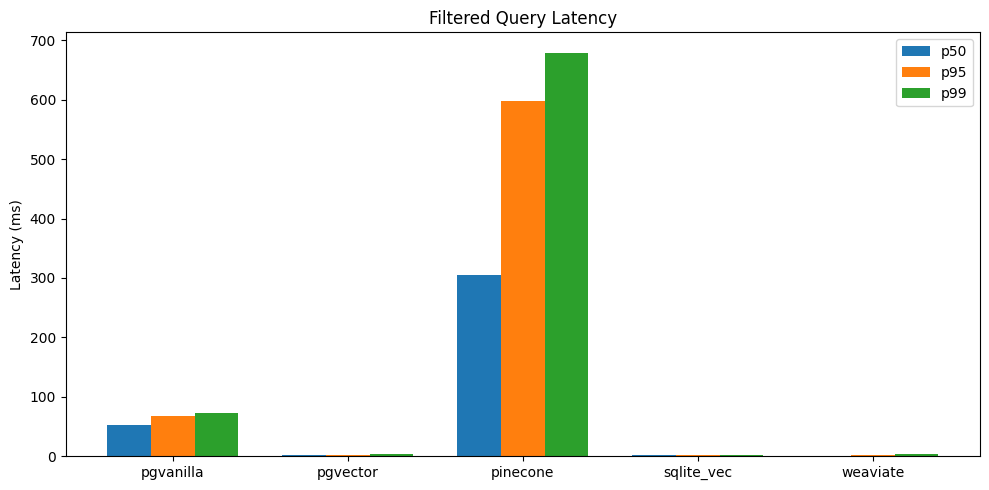

,adapter,p50_ms,p95_ms,p99_ms,qps
0,sqlite_vec,2.265761,2.619405,2.694990,432.64
1,weaviate,1.035742,1.674427,3.060301,876.01
2,pgvector,1.308746,1.869035,3.415968,717.38
3,pgvanilla,52.670707,67.107823,72.302513,18.76
4,pinecone,305.463006,597.144342,679.576063,2.80


In [4]:
# Chart 3: Filtered query latency (p50/p95/p99)
df = load_results("query")
df_filt = df[df["operation"] == "query_filtered"]
if df_filt.empty:
    print("No filtered query results found. Run benchmark_query.py first.")
else:
    x = range(len(df_filt))
    width = 0.25
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar([i - width for i in x], df_filt["p50_ms"], width, label="p50")
    ax.bar(list(x), df_filt["p95_ms"], width, label="p95")
    ax.bar([i + width for i in x], df_filt["p99_ms"], width, label="p99")
    ax.set_xticks(list(x))
    ax.set_xticklabels(df_filt["adapter"].tolist())
    ax.set_ylabel("Latency (ms)")
    ax.set_title("Filtered Query Latency")
    ax.legend()
    plt.tight_layout()
    plt.show()
    display(df_filt[["adapter", "p50_ms", "p95_ms", "p99_ms", "qps"]].sort_values("p99_ms").reset_index(drop=True))

**How to read this chart:** Same as Chart 2 — **lower bars are better**. If filtered query latency is much higher than ANN latency for an adapter, it handles metadata filtering inefficiently. Prefer the adapter whose filtered p99 stays closest to its ANN p99.

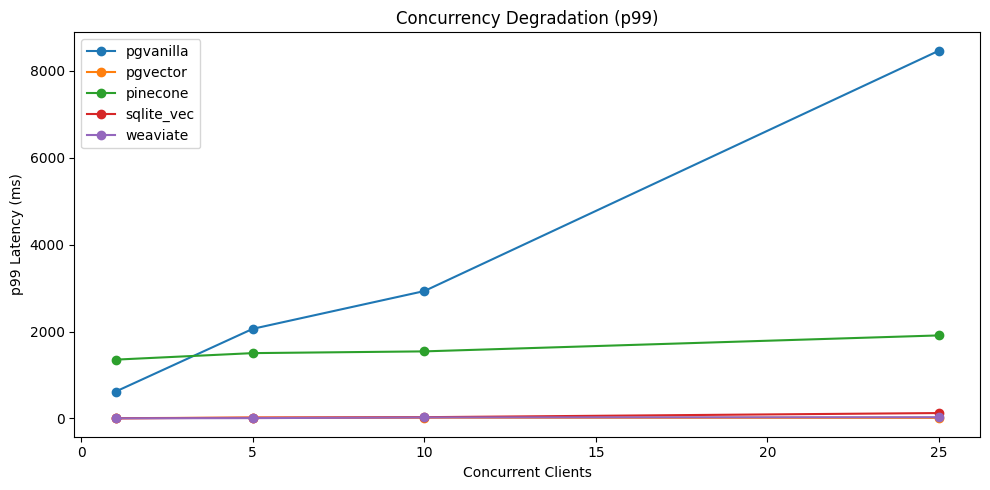

,adapter,clients,qps,p50_ms,p99_ms
0,sqlite_vec,1,488.98,1.917283,3.161953
1,weaviate,1,455.06,1.756664,4.278596
2,pgvector,1,328.08,1.874074,6.654809
3,pgvanilla,1,2.02,486.513571,618.150777
4,pinecone,1,2.94,309.145166,1354.016064
5,weaviate,5,1186.05,3.843309,8.267955
6,sqlite_vec,5,733.88,5.865776,18.584764
7,pgvector,5,153.29,8.131428,20.593619
8,pinecone,5,13.11,302.035935,1504.084700
9,pgvanilla,5,3.53,1376.547270,2063.116029


In [5]:
# Chart 4: Concurrency degradation — p99 latency vs client count
df = load_results("concurrency")
if df.empty:
    print("No concurrency results found. Run benchmark_concurrency.py first.")
else:
    fig, ax = plt.subplots(figsize=(10, 5))
    for adapter, grp in df.groupby("adapter"):
        grp_sorted = grp.sort_values("clients")
        ax.plot(grp_sorted["clients"], grp_sorted["p99_ms"], marker="o", label=adapter)
    ax.set_xlabel("Concurrent Clients")
    ax.set_ylabel("p99 Latency (ms)")
    ax.set_title("Concurrency Degradation (p99)")
    ax.legend()
    plt.tight_layout()
    plt.show()
    display(df[["adapter", "clients", "qps", "p50_ms", "p99_ms"]].sort_values(["clients", "p99_ms"]).reset_index(drop=True))

**How to read this chart:** A **flatter line** means the adapter degrades less under load — better for concurrent workloads. A steep upward curve means latency spikes as clients increase. Look for the adapter whose p99 line rises the least from left to right.

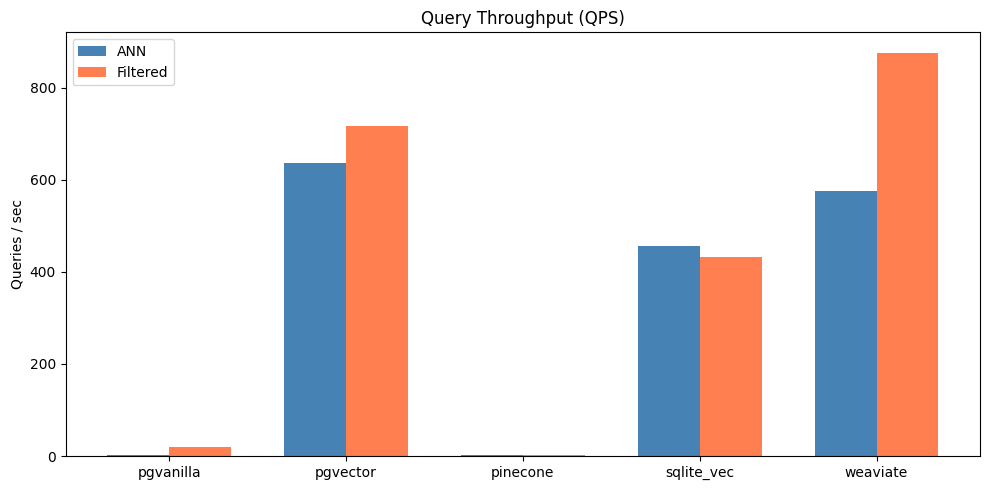

,adapter,ann_qps,filtered_qps,filtered_vs_ann_%
0,pgvector,635.33,717.38,112.9
1,weaviate,576.22,876.01,152.0
2,sqlite_vec,456.51,432.64,94.8
3,pinecone,2.99,2.80,93.6
4,pgvanilla,1.97,18.76,952.3


In [6]:
# Chart 5: Query QPS (throughput) — ANN and filtered side by side
df = load_results("query")
if df.empty:
    print("No query results found.")
else:
    df_ann  = df[df["operation"] == "query_ann"].set_index("adapter")
    df_filt = df[df["operation"] == "query_filtered"].set_index("adapter")
    adapters = df_ann.index.tolist()
    x = range(len(adapters))
    width = 0.35
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar([i - width/2 for i in x], df_ann.loc[adapters, "qps"],  width, label="ANN",      color="steelblue")
    ax.bar([i + width/2 for i in x], df_filt.loc[adapters, "qps"], width, label="Filtered",  color="coral")
    ax.set_xticks(list(x))
    ax.set_xticklabels(adapters)
    ax.set_ylabel("Queries / sec")
    ax.set_title("Query Throughput (QPS)")
    ax.legend()
    plt.tight_layout()
    plt.show()
    qps_summary = pd.DataFrame({
        "adapter": adapters,
        "ann_qps": df_ann.loc[adapters, "qps"].values,
        "filtered_qps": df_filt.loc[adapters, "qps"].values,
    })
    qps_summary["filtered_vs_ann_%"] = (qps_summary["filtered_qps"] / qps_summary["ann_qps"] * 100).round(1)
    display(qps_summary.sort_values("ann_qps", ascending=False).reset_index(drop=True))

**How to read this chart:** **Taller bars are better** (more queries per second). Compare ANN vs. Filtered bars side by side for each adapter — a large drop from ANN to Filtered indicates the adapter struggles with metadata filtering at scale. The overall best adapter maximizes both bars.

In [7]:
# Scorecard: normalize each metric to 0–1 and rank adapters
# Higher score = better. Latency metrics are inverted (lower latency → higher score).
import numpy as np

def norm_higher(s): return (s - s.min()) / (s.max() - s.min() + 1e-9)
def norm_lower(s):  return 1 - norm_higher(s)

di = load_results("insert").set_index("adapter")
dq = load_results("query")
dqa = dq[dq["operation"] == "query_ann"].set_index("adapter")
dqf = dq[dq["operation"] == "query_filtered"].set_index("adapter")
dc  = load_results("concurrency")
dc_max = dc[dc["clients"] == dc["clients"].max()].set_index("adapter")

adapters = sorted(set(di.index) & set(dqa.index) & set(dqf.index) & set(dc_max.index))

scorecard = pd.DataFrame(index=adapters)
scorecard["insert_rps"]       = norm_higher(di.loc[adapters, "records_per_sec"])
scorecard["ann_p50"]          = norm_lower(dqa.loc[adapters, "p50_ms"])
scorecard["ann_p99"]          = norm_lower(dqa.loc[adapters, "p99_ms"])
scorecard["filtered_p50"]     = norm_lower(dqf.loc[adapters, "p50_ms"])
scorecard["filtered_p99"]     = norm_lower(dqf.loc[adapters, "p99_ms"])
scorecard["concurrency_qps"]  = norm_higher(dc_max.loc[adapters, "qps"])
scorecard["concurrency_p99"]  = norm_lower(dc_max.loc[adapters, "p99_ms"])
scorecard["overall"]          = scorecard.mean(axis=1)
scorecard = scorecard.sort_values("overall", ascending=False)

print("=== Scorecard (0 = worst, 1 = best) ===\n")
print(scorecard.round(3).to_string())
print(f"\nOverall winner: {scorecard.index[0].upper()}")

=== Scorecard (0 = worst, 1 = best) ===

            insert_rps  ann_p50  ann_p99  filtered_p50  filtered_p99  concurrency_qps  concurrency_p99  overall
sqlite_vec       1.000    0.999    1.000         0.996         1.000            0.251            0.987    0.890
weaviate         0.229    1.000    0.999         1.000         0.999            1.000            0.998    0.889
pgvector         0.015    1.000    1.000         0.999         0.999            0.132            1.000    0.735
pgvanilla        0.042    0.000    0.301         0.830         0.897            0.000            0.000    0.296
pinecone         0.000    0.383    0.000         0.000         0.000            0.027            0.775    0.169

Overall winner: SQLITE_VEC


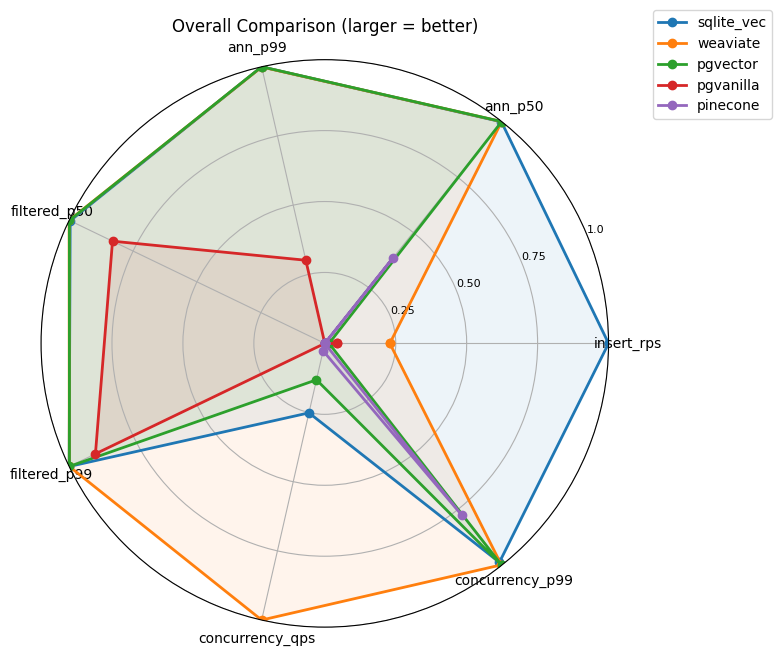

In [8]:
# Chart 6: Radar chart — all dimensions at once
labels = ["insert_rps", "ann_p50", "ann_p99", "filtered_p50", "filtered_p99", "concurrency_qps", "concurrency_p99"]
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = plt.cm.tab10.colors

for i, adapter in enumerate(scorecard.index):
    values = scorecard.loc[adapter, labels].tolist()
    values += values[:1]
    ax.plot(angles, values, "o-", linewidth=2, label=adapter, color=colors[i % len(colors)])
    ax.fill(angles, values, alpha=0.08, color=colors[i % len(colors)])

ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0.25", "0.50", "0.75", "1.0"], fontsize=8)
ax.set_title("Overall Comparison (larger = better)", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()


In [9]:
# Summary: per-use-case recommendation
di_raw  = load_results("insert").set_index("adapter")
dqa_raw = load_results("query")[lambda d: d["operation"] == "query_ann"].set_index("adapter")
dc_raw  = load_results("concurrency")
dc_max_raw = dc_raw[dc_raw["clients"] == dc_raw["clients"].max()].set_index("adapter")

best_insert      = di_raw["records_per_sec"].idxmax()
best_ann_latency = dqa_raw["p50_ms"].idxmin()
best_ann_qps     = dqa_raw["qps"].idxmax()
best_concurrent  = dc_max_raw["qps"].idxmax()
best_overall     = scorecard.index[0]

print("========================================")
print("        USE-CASE RECOMMENDATIONS        ")
print("========================================")
print(f"  Bulk ingestion speed     →  {best_insert}")
print(f"  Lowest ANN latency (p50) →  {best_ann_latency}")
print(f"  Highest single-client QPS→  {best_ann_qps}")
print(f"  Best under concurrency   →  {best_concurrent}")
print(f"  Best overall (balanced)  →  {best_overall}")
print("========================================")
print()

notes = {
    "sqlite_vec": "Embedded, zero-infra, great for single-process or edge workloads.",
    "pgvector":   "Best if you already run Postgres; transactional + vector in one DB.",
    "pgvanilla":  "Vanilla Postgres baseline (no extensions); brute-force cosine via SQL.",
    "weaviate":   "Purpose-built vector DB; rich filtering and schema support.",
    "pinecone":   "Fully managed cloud; no ops overhead but adds network latency.",
}
for adapter in scorecard.index:
    note = notes.get(adapter, "")
    score = scorecard.loc[adapter, "overall"]
    print(f"  {adapter:<14} (score {score:.2f})  {note}")

        USE-CASE RECOMMENDATIONS        
  Bulk ingestion speed     →  sqlite_vec
  Lowest ANN latency (p50) →  pgvector
  Highest single-client QPS→  pgvector
  Best under concurrency   →  weaviate
  Best overall (balanced)  →  sqlite_vec

  sqlite_vec     (score 0.89)  Embedded, zero-infra, great for single-process or edge workloads.
  weaviate       (score 0.89)  Purpose-built vector DB; rich filtering and schema support.
  pgvector       (score 0.73)  Best if you already run Postgres; transactional + vector in one DB.
  pgvanilla      (score 0.30)  Vanilla Postgres baseline (no extensions); brute-force cosine via SQL.
  pinecone       (score 0.17)  Fully managed cloud; no ops overhead but adds network latency.


# Vector DB Benchmark — Glossary

## Latency Percentiles

| Term | Full Name | What it means |
|------|-----------|----------------|
| **p50** | 50th percentile (median) | Half of all queries completed faster than this. Represents the *typical* user experience. |
| **p95** | 95th percentile | 95% of queries were faster than this. Starts to reveal occasional slow outliers. |
| **p99** | 99th percentile (tail latency) | 99% of queries were faster than this. The worst-case latency most users will ever see. Use this to judge consistency under load. |

> **Rule of thumb:** p50 shows average performance; p99 shows whether the system has latency spikes. A good database has a small gap between p50 and p99.

---

## Throughput

| Term | Full Name | What it means |
|------|-----------|----------------|
| **QPS** | Queries Per Second | How many search queries the database can handle per second. Higher = better. |
| **records/sec** (RPS) | Records Per Second | How many records can be inserted per second during bulk ingestion. Higher = better. |

---

## Query Types

| Term | Full Name | What it means |
|------|-----------|----------------|
| **ANN** | Approximate Nearest Neighbor | The core vector search operation — finds the *k* most similar vectors to a query vector. "Approximate" means it trades a small accuracy loss for much faster speed compared to exact search. |
| **Filtered query** | Metadata-filtered ANN search | ANN search combined with a metadata condition (e.g. `category = "news"`). Harder than plain ANN — databases must narrow the vector space while respecting the filter. |

---

## Load & Infrastructure

| Term | Full Name | What it means |
|------|-----------|----------------|
| **Concurrent clients** | Simultaneous connections | Number of parallel threads/processes sending queries at the same time. Higher concurrency stresses the database and reveals how latency degrades under real-world multi-user load. |
| **Concurrency degradation** | Latency growth under load | How much p99 latency increases as concurrent clients go up. A flat curve means the adapter scales well; a steep curve means bottlenecks under load. |
| **Adapter** | Database driver/connector | The wrapper used to talk to each vector database (pgvector, pgvanilla, sqlite_vec, weaviate, pinecone). Each adapter implements the same benchmark interface so results are comparable. |

---

## Scoring

| Term | What it means |
|------|----------------|
| **Normalized score (0–1)** | Each metric is scaled so 1.0 = best adapter on that metric, 0.0 = worst. Allows apples-to-apples comparison across metrics with different units. |
| **Overall score** | Simple average of all normalized metric scores. Higher = better balanced across all dimensions. |

## Before vs After Comparison

Compares `baseline` (original code) against `optimized_v2` (all optimisations applied).

Set the labels below then run all cells.

In [10]:
import numpy as np

BEFORE_LABEL = "baseline"
AFTER_LABEL  = "optimized_v2"

def load_comparison(operation):
    import glob as _glob
    all_records = []
    for path in _glob.glob("results/*.json"):
        with open(path) as f:
            r = json.load(f)
        r.setdefault("label", "baseline")
        all_records.append(r)

    if not all_records:
        return pd.DataFrame(), pd.DataFrame()

    df = pd.DataFrame(all_records)
    df = df[df["operation"] == operation]

    before = (df[df["label"] == BEFORE_LABEL]
              .sort_values("timestamp")
              .groupby("adapter").last())
    after  = (df[df["label"] == AFTER_LABEL]
              .sort_values("timestamp")
              .groupby("adapter").last())
    return before, after


def load_label(operation, label):
    import glob as _glob
    records = []
    for path in _glob.glob("results/*.json"):
        with open(path) as f:
            r = json.load(f)
        r.setdefault("label", "baseline")
        if r.get("label") == label and r.get("operation") == operation:
            records.append(r)
    if not records:
        return pd.DataFrame()
    df = pd.DataFrame(records)
    return df.sort_values("timestamp").groupby("adapter").last()


def get_throughput_col(df, operation):
    if operation == "insert" and "records_per_sec" in df.columns:
        return df["records_per_sec"]
    return df["qps"]

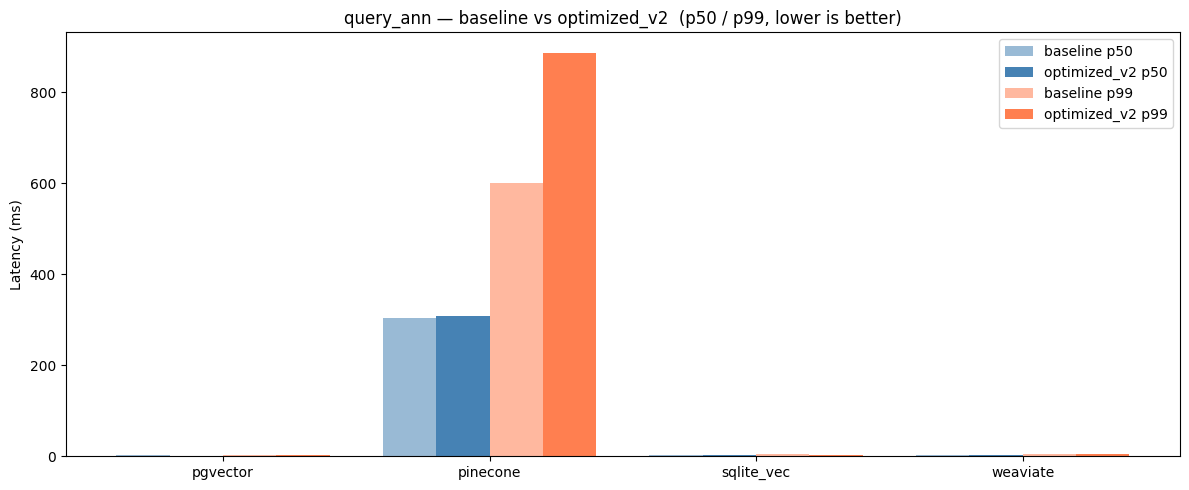

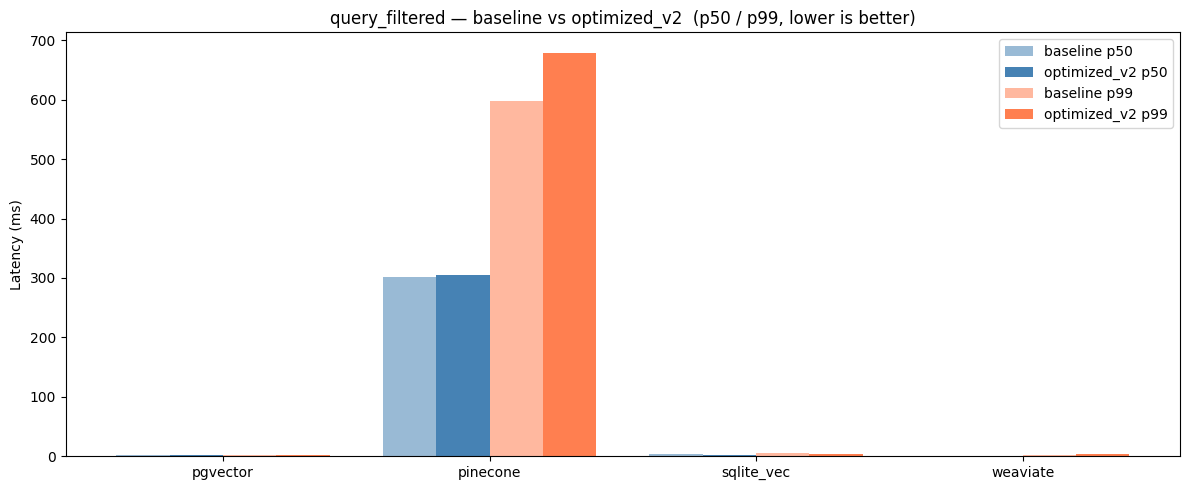

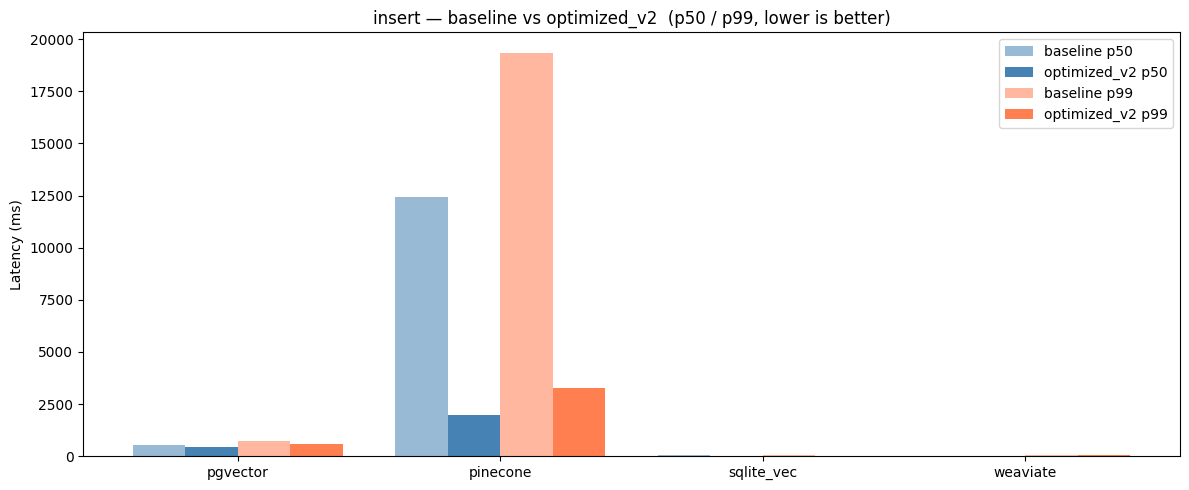

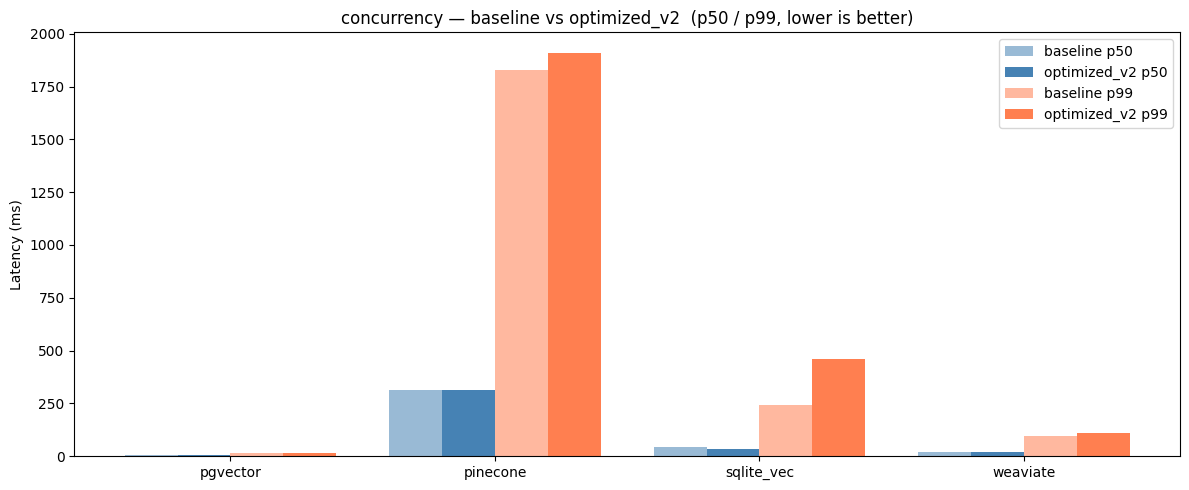

In [11]:
# Grouped bar chart: before/after p50 and p99 per adapter, per operation
for op in ["query_ann", "query_filtered", "insert", "concurrency"]:
    before, after = load_comparison(op)
    if before.empty or after.empty:
        print(f"No {BEFORE_LABEL}/{AFTER_LABEL} comparison data for {op} — run benchmarks with --label first.")
        continue

    adapters = sorted(set(before.index) & set(after.index))
    if not adapters:
        continue

    x = np.arange(len(adapters))
    width = 0.2

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x - 1.5 * width, before.loc[adapters, "p50_ms"], width,
           label=f"{BEFORE_LABEL} p50", color="steelblue", alpha=0.55)
    ax.bar(x - 0.5 * width, after.loc[adapters, "p50_ms"],  width,
           label=f"{AFTER_LABEL} p50",  color="steelblue")
    ax.bar(x + 0.5 * width, before.loc[adapters, "p99_ms"], width,
           label=f"{BEFORE_LABEL} p99", color="coral", alpha=0.55)
    ax.bar(x + 1.5 * width, after.loc[adapters, "p99_ms"],  width,
           label=f"{AFTER_LABEL} p99",  color="coral")

    ax.set_xticks(x)
    ax.set_xticklabels(adapters)
    ax.set_ylabel("Latency (ms)")
    ax.set_title(f"{op} — {BEFORE_LABEL} vs {AFTER_LABEL}  (p50 / p99, lower is better)")
    ax.legend()
    plt.tight_layout()
    plt.show()

In [12]:
# % improvement table — green = improvement, red = regression
def color_delta(val, lower_is_better=True):
    if pd.isna(val):
        return ""
    if lower_is_better:
        if val < -1:
            return "background-color: #c6efce; color: #276221"
        if val > 1:
            return "background-color: #ffc7ce; color: #9c0006"
    else:
        if val > 1:
            return "background-color: #c6efce; color: #276221"
        if val < -1:
            return "background-color: #ffc7ce; color: #9c0006"
    return ""


for op in ["query_ann", "query_filtered", "insert", "concurrency"]:
    before, after = load_comparison(op)
    if before.empty or after.empty:
        continue

    adapters = sorted(set(before.index) & set(after.index))
    if not adapters:
        continue

    thr_before = get_throughput_col(before.loc[adapters], op)
    thr_after  = get_throughput_col(after.loc[adapters],  op)

    def pct(bv, av):
        return round((av - bv) / bv * 100, 1) if bv else 0.0

    rows = []
    for adapter in adapters:
        b, a = before.loc[adapter], after.loc[adapter]
        rows.append({
            "adapter":    adapter,
            "p50 before": round(b["p50_ms"], 2),
            "p50 after":  round(a["p50_ms"], 2),
            "p50 Δ%":     pct(b["p50_ms"], a["p50_ms"]),
            "p99 before": round(b["p99_ms"], 2),
            "p99 after":  round(a["p99_ms"], 2),
            "p99 Δ%":     pct(b["p99_ms"], a["p99_ms"]),
            "thru before": round(thr_before.loc[adapter], 2),
            "thru after":  round(thr_after.loc[adapter],  2),
            "thru Δ%":    pct(thr_before.loc[adapter], thr_after.loc[adapter]),
        })

    tbl = pd.DataFrame(rows).set_index("adapter")
    print(f"\n{'='*60}\n  {op.upper()}  ({BEFORE_LABEL} → {AFTER_LABEL})\n{'='*60}")
    styled = (tbl.style
                 .map(lambda v: color_delta(v, lower_is_better=True),  subset=["p50 Δ%", "p99 Δ%"])
                 .map(lambda v: color_delta(v, lower_is_better=False), subset=["thru Δ%"])
                 .format("{:.2f}", subset=["p50 before", "p50 after", "p99 before", "p99 after",
                                           "thru before", "thru after"])
                 .format("{:+.1f}%", subset=["p50 Δ%", "p99 Δ%", "thru Δ%"]))
    display(styled)


  QUERY_ANN  (baseline → optimized_v2)


,p50 before,p50 after,p50 Δ%,p99 before,p99 after,p99 Δ%,thru before,thru after,thru Δ%
adapter,,,,,,,,,
pgvector,1.48,1.38,-6.7%,2.99,3.46,+15.5%,643.06,639.36,-0.6%
pinecone,302.94,308.11,+1.7%,599.65,887.04,+47.9%,3.11,2.99,-3.9%
sqlite_vec,3.18,2.06,-35.2%,4.03,2.60,-35.5%,304.64,466.75,+53.2%
weaviate,1.58,1.43,-9.8%,4.62,3.69,-20.0%,553.79,649.14,+17.2%



  QUERY_FILTERED  (baseline → optimized_v2)


,p50 before,p50 after,p50 Δ%,p99 before,p99 after,p99 Δ%,thru before,thru after,thru Δ%
adapter,,,,,,,,,
pgvector,1.29,1.23,-4.5%,2.33,1.82,-21.7%,739.11,794.47,+7.5%
pinecone,301.69,305.46,+1.2%,598.48,679.58,+13.5%,3.19,2.80,-12.2%
sqlite_vec,3.70,2.56,-30.7%,4.64,3.02,-34.8%,260.24,385.60,+48.2%
weaviate,1.01,1.04,+2.4%,2.10,3.44,+64.2%,935.94,902.62,-3.6%



  INSERT  (baseline → optimized_v2)


,p50 before,p50 after,p50 Δ%,p99 before,p99 after,p99 Δ%,thru before,thru after,thru Δ%
adapter,,,,,,,,,
pgvector,553.39,457.20,-17.4%,738.15,568.48,-23.0%,192.50,230.97,+20.0%
pinecone,12425.65,1957.98,-84.2%,19358.07,3273.93,-83.1%,8.28,44.62,+438.9%
sqlite_vec,33.46,10.25,-69.4%,54.55,22.19,-59.3%,3232.47,6596.42,+104.1%
weaviate,27.55,25.95,-5.8%,38.60,63.01,+63.2%,3375.40,2831.04,-16.1%



  CONCURRENCY  (baseline → optimized_v2)


,p50 before,p50 after,p50 Δ%,p99 before,p99 after,p99 Δ%,thru before,thru after,thru Δ%
adapter,,,,,,,,,
pgvector,5.93,6.45,+8.8%,15.24,16.17,+6.1%,177.04,161.45,-8.8%
pinecone,313.89,311.34,-0.8%,1829.52,1911.43,+4.5%,36.04,37.41,+3.8%
sqlite_vec,42.17,35.99,-14.6%,240.28,460.28,+91.6%,215.39,163.99,-23.9%
weaviate,21.76,18.26,-16.1%,97.49,111.13,+14.0%,616.26,632.57,+2.6%


In [13]:
# Scorecard: baseline vs optimized_v2 — per-metric and overall rankings for both runs
def load_results_labeled(prefix, label):
    import glob as _glob
    records = []
    for path in _glob.glob(f"results/{prefix}_*.json"):
        with open(path) as f:
            r = json.load(f)
        r.setdefault("label", "baseline")
        if r.get("label") == label:
            records.append(r)
    if not records:
        return pd.DataFrame()
    df = pd.DataFrame(records)
    df = df.sort_values("timestamp").groupby(["adapter", "operation", "clients"], as_index=False).last()
    return df


def compute_scorecard(label):
    di  = load_results_labeled("insert",      label)
    dq  = load_results_labeled("query",       label)
    dc  = load_results_labeled("concurrency", label)

    if di.empty or dq.empty or dc.empty:
        return pd.DataFrame(), label

    di  = di.set_index("adapter")
    dqa = dq[dq["operation"] == "query_ann"].set_index("adapter")
    dqf = dq[dq["operation"] == "query_filtered"].set_index("adapter")
    dc_max = dc[dc["clients"] == dc["clients"].max()].set_index("adapter")

    adapters = sorted(set(di.index) & set(dqa.index) & set(dqf.index) & set(dc_max.index))
    if not adapters:
        return pd.DataFrame(), label

    def norm_higher(s): return (s - s.min()) / (s.max() - s.min() + 1e-9)
    def norm_lower(s):  return 1 - norm_higher(s)

    sc = pd.DataFrame(index=adapters)
    sc["insert_rps"]      = norm_higher(di.loc[adapters, "records_per_sec"])
    sc["ann_p50"]         = norm_lower(dqa.loc[adapters, "p50_ms"])
    sc["ann_p99"]         = norm_lower(dqa.loc[adapters, "p99_ms"])
    sc["filtered_p50"]    = norm_lower(dqf.loc[adapters, "p50_ms"])
    sc["filtered_p99"]    = norm_lower(dqf.loc[adapters, "p99_ms"])
    sc["concurrency_qps"] = norm_higher(dc_max.loc[adapters, "qps"])
    sc["concurrency_p99"] = norm_lower(dc_max.loc[adapters, "p99_ms"])
    sc["overall"]         = sc.mean(axis=1)
    return sc.sort_values("overall", ascending=False), label


for label in [BEFORE_LABEL, AFTER_LABEL]:
    sc, lbl = compute_scorecard(label)
    if sc.empty:
        print(f"No data for label '{lbl}' — run benchmarks with --label {lbl} first.\n")
        continue

    print(f"\n{'='*55}")
    print(f"  SCORECARD — {lbl.upper()}  (0 = worst, 1 = best)")
    print(f"{'='*55}")
    display(sc.round(3).style.highlight_max(color="#11471c", axis=0).format("{:.3f}"))

    notes = {
        "sqlite_vec": "Embedded, zero-infra, great for single-process or edge.",
        "pgvector":   "Transactional + vector in one DB if you already run Postgres.",
        "pgvanilla":  "Vanilla Postgres baseline (no extensions); brute-force cosine via SQL.",
        "weaviate":   "Purpose-built vector DB; rich filtering and schema support.",
        "pinecone":   "Fully managed cloud; no ops overhead but adds network latency.",
    }
    print(f"\n  Overall winner ({lbl}): {sc.index[0].upper()}\n")
    for adapter in sc.index:
        note  = notes.get(adapter, "")
        score = sc.loc[adapter, "overall"]
        best_metric = sc.loc[adapter, sc.columns[:-1]].idxmax()
        print(f"  {adapter:<14} overall={score:.3f}  best at: {best_metric:<20}  {note}")
    print()


  SCORECARD — BASELINE  (0 = worst, 1 = best)


,insert_rps,ann_p50,ann_p99,filtered_p50,filtered_p99,concurrency_qps,concurrency_p99,overall
weaviate,1.000,1.000,0.997,1.000,1.000,1.000,0.955,0.993
sqlite_vec,0.958,0.994,0.998,0.991,0.996,0.309,0.876,0.875
pgvector,0.055,1.000,1.000,0.999,1.000,0.243,1.000,0.757
pinecone,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000



  Overall winner (baseline): WEAVIATE

  weaviate       overall=0.993  best at: filtered_p50          Purpose-built vector DB; rich filtering and schema support.
  sqlite_vec     overall=0.875  best at: ann_p99               Embedded, zero-infra, great for single-process or edge.
  pgvector       overall=0.757  best at: ann_p50               Transactional + vector in one DB if you already run Postgres.
  pinecone       overall=0.000  best at: filtered_p50          Fully managed cloud; no ops overhead but adds network latency.


  SCORECARD — OPTIMIZED_V2  (0 = worst, 1 = best)


,insert_rps,ann_p50,ann_p99,filtered_p50,filtered_p99,concurrency_qps,concurrency_p99,overall
weaviate,0.425,1.000,0.999,1.000,0.998,1.000,0.950,0.910
sqlite_vec,1.000,0.998,1.000,0.995,0.998,0.213,0.766,0.853
pgvector,0.028,1.000,0.999,0.999,1.000,0.208,1.000,0.748
pinecone,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000



  Overall winner (optimized_v2): WEAVIATE

  weaviate       overall=0.910  best at: filtered_p50          Purpose-built vector DB; rich filtering and schema support.
  sqlite_vec     overall=0.853  best at: ann_p99               Embedded, zero-infra, great for single-process or edge.
  pgvector       overall=0.748  best at: ann_p50               Transactional + vector in one DB if you already run Postgres.
  pinecone       overall=0.000  best at: filtered_p50          Fully managed cloud; no ops overhead but adds network latency.



## pgvector (HNSW) vs Vanilla PostgreSQL (brute-force)

Head-to-head comparison showing the value the pgvector extension provides over raw PostgreSQL with pure-SQL cosine distance.

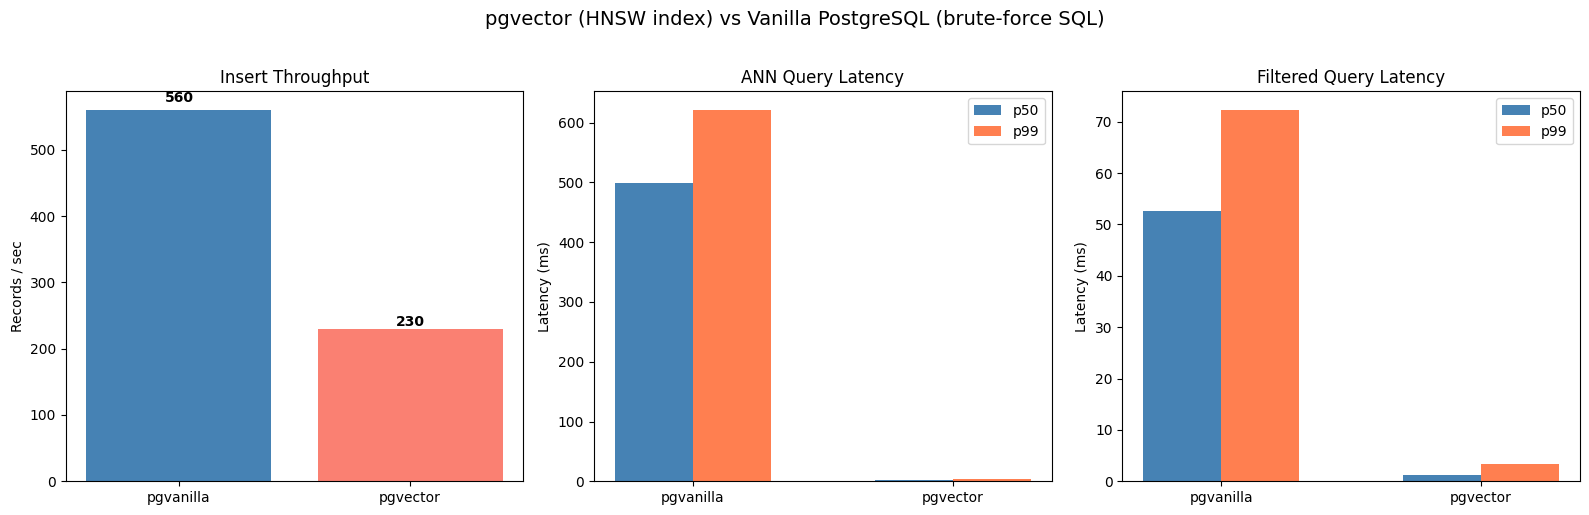

,insert_rps,ann_p50_ms,ann_p99_ms,ann_qps,filtered_p50_ms,filtered_p99_ms,filtered_qps
adapter,,,,,,,
pgvector,230.0,1.34,3.44,635.3,1.31,3.42,717.4
pgvanilla,560.1,498.39,621.44,2.0,52.67,72.30,18.8



pgvector ANN query is 373.1x faster than vanilla PostgreSQL (p50)
pgvector filtered query is 40.2x faster than vanilla PostgreSQL (p50)


In [14]:
# pgvector vs pgvanilla — head-to-head comparison
PG_ADAPTERS = ["pgvector", "pgvanilla"]

def _pg_pair(prefix, operation=None):
    df = load_results(prefix)
    if df.empty:
        return pd.DataFrame()
    if operation:
        df = df[df["operation"] == operation]
    return df[df["adapter"].isin(PG_ADAPTERS)].set_index("adapter")

# --- Insert throughput ---
di = _pg_pair("insert")
if di.empty or len(di) < 2:
    print("Need both pgvector and pgvanilla insert results. Run benchmarks with --adapters pgvector,pgvanilla first.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Insert throughput
    axes[0].bar(di.index, di["records_per_sec"], color=["steelblue", "salmon"])
    axes[0].set_ylabel("Records / sec")
    axes[0].set_title("Insert Throughput")
    for i, v in enumerate(di["records_per_sec"]):
        axes[0].text(i, v + v * 0.02, f"{v:.0f}", ha="center", fontweight="bold")

    # ANN query latency
    dqa = _pg_pair("query", "query_ann")
    if not dqa.empty and len(dqa) >= 2:
        x = range(len(dqa))
        w = 0.3
        axes[1].bar([i - w/2 for i in x], dqa["p50_ms"], w, label="p50", color="steelblue")
        axes[1].bar([i + w/2 for i in x], dqa["p99_ms"], w, label="p99", color="coral")
        axes[1].set_xticks(list(x))
        axes[1].set_xticklabels(dqa.index.tolist())
        axes[1].set_ylabel("Latency (ms)")
        axes[1].set_title("ANN Query Latency")
        axes[1].legend()

    # Filtered query latency
    dqf = _pg_pair("query", "query_filtered")
    if not dqf.empty and len(dqf) >= 2:
        x = range(len(dqf))
        axes[2].bar([i - w/2 for i in x], dqf["p50_ms"], w, label="p50", color="steelblue")
        axes[2].bar([i + w/2 for i in x], dqf["p99_ms"], w, label="p99", color="coral")
        axes[2].set_xticks(list(x))
        axes[2].set_xticklabels(dqf.index.tolist())
        axes[2].set_ylabel("Latency (ms)")
        axes[2].set_title("Filtered Query Latency")
        axes[2].legend()

    plt.suptitle("pgvector (HNSW index) vs Vanilla PostgreSQL (brute-force SQL)", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    # Summary table
    rows = []
    for adapter in PG_ADAPTERS:
        row = {"adapter": adapter}
        if adapter in di.index:
            row["insert_rps"] = round(di.loc[adapter, "records_per_sec"], 1)
        if not dqa.empty and adapter in dqa.index:
            row["ann_p50_ms"] = round(dqa.loc[adapter, "p50_ms"], 2)
            row["ann_p99_ms"] = round(dqa.loc[adapter, "p99_ms"], 2)
            row["ann_qps"] = round(dqa.loc[adapter, "qps"], 1)
        if not dqf.empty and adapter in dqf.index:
            row["filtered_p50_ms"] = round(dqf.loc[adapter, "p50_ms"], 2)
            row["filtered_p99_ms"] = round(dqf.loc[adapter, "p99_ms"], 2)
            row["filtered_qps"] = round(dqf.loc[adapter, "qps"], 1)
        rows.append(row)
    summary = pd.DataFrame(rows).set_index("adapter")
    display(summary)

    # Speedup factors
    if not dqa.empty and len(dqa) >= 2:
        speedup_ann = dqa.loc["pgvanilla", "p50_ms"] / dqa.loc["pgvector", "p50_ms"]
        print(f"\npgvector ANN query is {speedup_ann:.1f}x faster than vanilla PostgreSQL (p50)")
    if not dqf.empty and len(dqf) >= 2:
        speedup_filt = dqf.loc["pgvanilla", "p50_ms"] / dqf.loc["pgvector", "p50_ms"]
        print(f"pgvector filtered query is {speedup_filt:.1f}x faster than vanilla PostgreSQL (p50)")

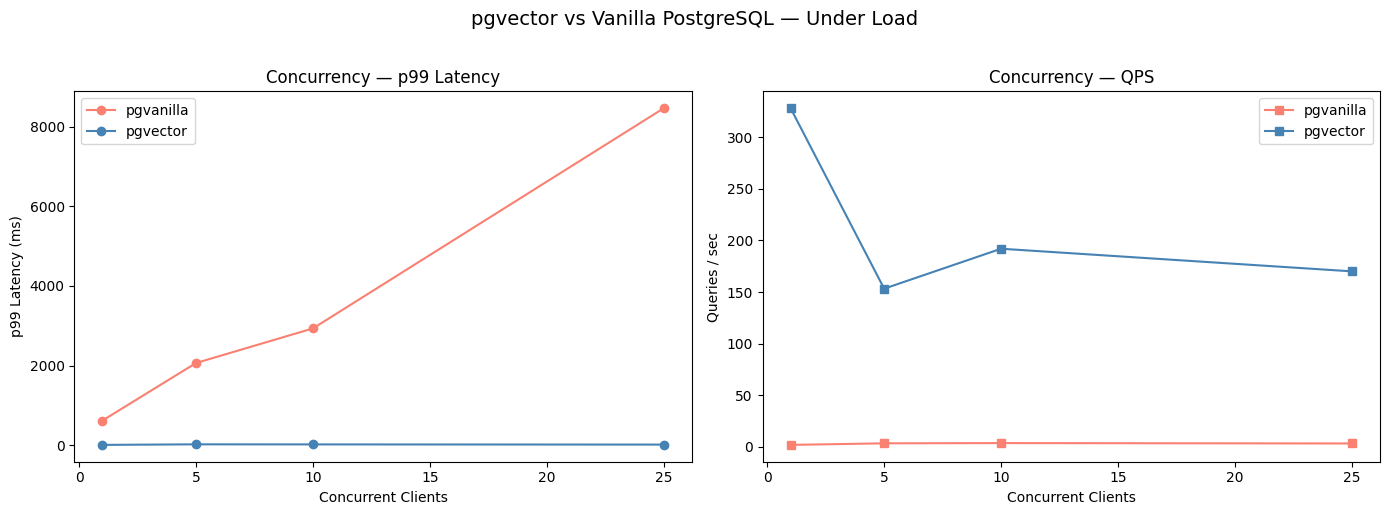

,adapter,clients,p50_ms,p99_ms,qps
0,pgvanilla,1,486.513571,618.150777,2.02
1,pgvector,1,1.874074,6.654809,328.08
2,pgvanilla,5,1376.547270,2063.116029,3.53
3,pgvector,5,8.131428,20.593619,153.29
4,pgvanilla,10,2634.287776,2931.991104,3.76
5,pgvector,10,6.490943,18.746131,191.97
6,pgvanilla,25,7042.502078,8463.229818,3.39
7,pgvector,25,6.105402,14.150151,170.06


In [15]:
# pgvector vs pgvanilla — concurrency comparison
dc = load_results("concurrency")
dc_pg = dc[dc["adapter"].isin(PG_ADAPTERS)] if not dc.empty else pd.DataFrame()

if dc_pg.empty or dc_pg["adapter"].nunique() < 2:
    print("Need both pgvector and pgvanilla concurrency results.")
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    for adapter, grp in dc_pg.groupby("adapter"):
        grp_sorted = grp.sort_values("clients")
        color = "steelblue" if adapter == "pgvector" else "salmon"
        ax1.plot(grp_sorted["clients"], grp_sorted["p99_ms"], marker="o", label=adapter, color=color)
        ax2.plot(grp_sorted["clients"], grp_sorted["qps"], marker="s", label=adapter, color=color)

    ax1.set_xlabel("Concurrent Clients")
    ax1.set_ylabel("p99 Latency (ms)")
    ax1.set_title("Concurrency — p99 Latency")
    ax1.legend()

    ax2.set_xlabel("Concurrent Clients")
    ax2.set_ylabel("Queries / sec")
    ax2.set_title("Concurrency — QPS")
    ax2.legend()

    plt.suptitle("pgvector vs Vanilla PostgreSQL — Under Load", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    display(dc_pg[["adapter", "clients", "p50_ms", "p99_ms", "qps"]].sort_values(["clients", "adapter"]).reset_index(drop=True))